In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [24]:
img = cv2.cvtColor(cv2.imread('bird.jpg'), cv2.COLOR_BGR2RGB)

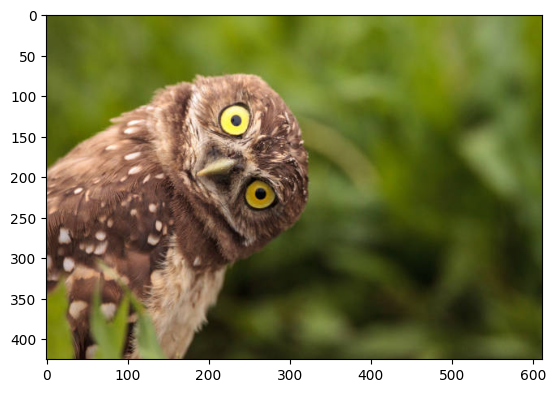

In [25]:
plt.imshow(img)
plt.show()

In [32]:
# Blur Filter - Average Filter
blur_filter3 = np.ones(shape=(3,3)) / 9
blur_filter7 =  np.ones(shape=(7,7)) / 49

# Applying a Filter in OpenCV

In OpenCV, a custom kernel is applied using the following function:

```python
cv2.filter2D(src, ddepth, kernel)
```

The main parameters are:

- **src**: the input image
- **ddepth**: the output data type (usually `-1` to preserve the image's original type)
- **kernel**: the desired kernel

This function performs the convolution operation across the entire image and returns the filtered image.

In [40]:
img_blur_filter3 = cv2.filter2D(img,-1,blur_filter3)
img_blur_filter7 = cv2.filter2D(img,-1,blur_filter7)

In [43]:
print("img shape :" , img.shape)
print("img dtype :" , img.dtype)

print(" img_blur_filter3 shape  :" , img_blur_filter3.shape)
print("img_blur_filter3 dtype :" , img_blur_filter3.dtype)

print(" img_blur_filter7 shape  :" , img_blur_filter7.shape)
print("img_blur_filter7 dtype :" , img_blur_filter7.dtype)

img shape : (425, 612, 3)
img dtype : uint8
 img_blur_filter3 shape  : (425, 612, 3)
img_blur_filter3 dtype : uint8
 img_blur_filter7 shape  : (425, 612, 3)
img_blur_filter7 dtype : uint8


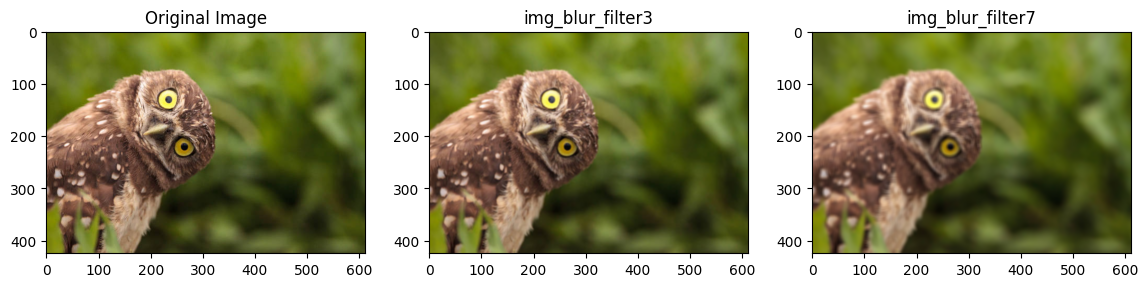

In [44]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1, 3, 2)
plt.title("img_blur_filter3")
plt.imshow(img_blur_filter3)

plt.subplot(1, 3, 3)
plt.title("img_blur_filter7")
plt.imshow(img_blur_filter7)


plt.show()


### Effect of Kernel Size

The larger the kernel, the more pixels participate in the averaging.

For example:

- A 3×3 kernel averages 9 pixels.
- A 7×7 kernel averages 49 pixels.

As a result:

- Smaller kernel → less blurring
- Larger kernel → more blurring

So increasing the kernel size makes the image smoother while reducing detail.


# Sharpen Filter

In [49]:
sharpen_filter = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

In [50]:
img_sharp = cv2.filter2D(img,-1,sharpen_filter)

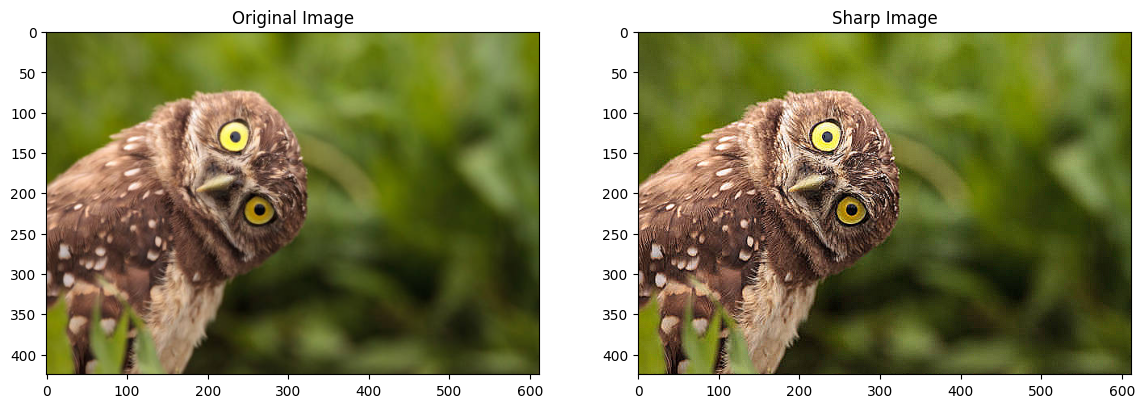

In [51]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.title("Sharp Image")
plt.imshow(img_sharp)
plt.show()


# Identity Filter

One of the simplest kernels is the **identity filter**.

In this kernel, only the center value equals 1, and all other elements are zero.

As a result, only the central pixel's value remains in the output, and no change is applied to the image.

That's why the output is exactly equal to the input image.

This filter is mainly used for understanding how kernels work and for testing algorithms.


In [52]:
identity_filter = np.array([[ 0,  0,  0],
                            [ 0,  1,  0],
                            [ 0,  0,  0]])

In [53]:
img_identity = cv2.filter2D(img,-1,identity_filter)

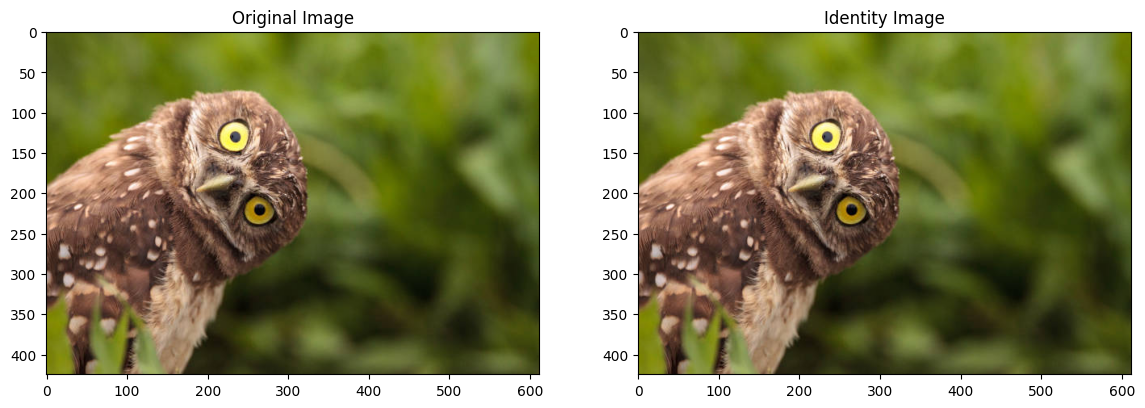

In [59]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.title("Identity Image")
plt.imshow(img_identity)
plt.show()

In [61]:
np.array_equal(img,img_identity)

True


# Shifting the Position of the Value 1 in the Kernel

If we move the value 1 from the center of the kernel to a different cell, the output will no longer equal the original image.

In this case, the image will **shift** in that same direction.

For example, if the value 1 is placed to the right of the center, the image shifts one pixel to the left.

So by changing the kernel's coefficients, many different kinds of processing can be performed on an image.


In [62]:
filter_un = np.array([[ 0,  0,  0,  0,  0],
                      [ 0,  0,  0,  0,  0],
                      [ 0,  0,  0,  0,  1],
                      [ 0,  0,  0,  0,  0],
                      [ 0,  0,  0,  0,  0]])

In [63]:
img_un = cv2.filter2D(img,-1,filter_un)

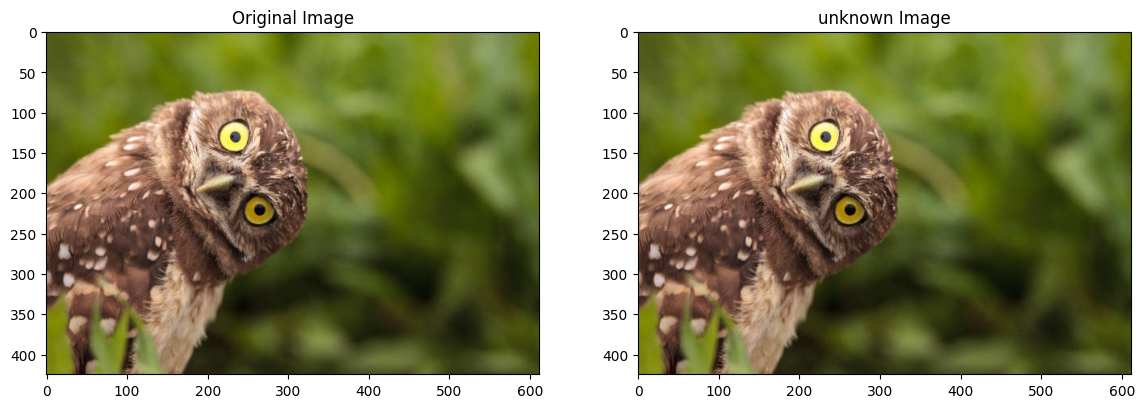

In [58]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1, 2, 2)
plt.title("unknown Image")
plt.imshow(img_un)
plt.show()